<a href="https://colab.research.google.com/github/dineshsnkumar/pytorch-for-deep-learning/blob/main/pytorch-fundamentals/image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install torch torchvision numpy matplotlib

### Data preperation

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [11]:
device = torch.device("cuda")

In [12]:
data_path = "./data"

#### Tranformation of data using Compose

In [13]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [16]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=mnist_transform
)

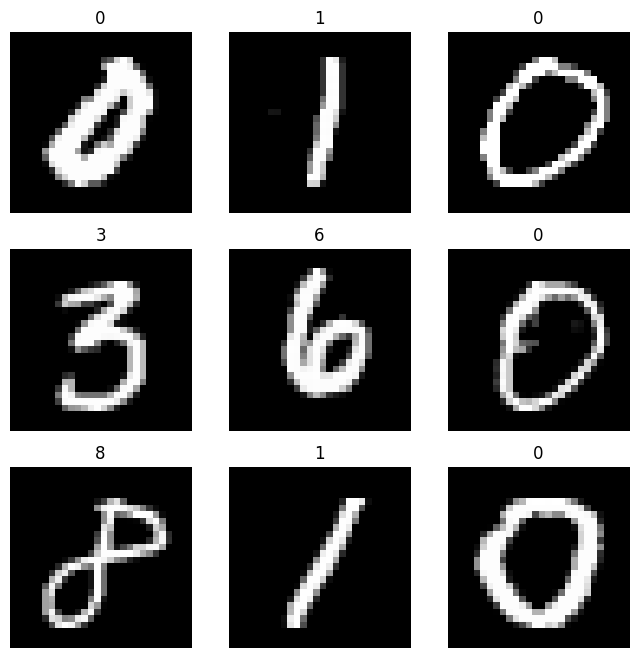

In [19]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols*rows + 1):
  sample_index = torch.randint(len(train_dataset), size=(1,)).item()
  img, label = train_dataset[sample_index]
  figure.add_subplot(rows, cols, i)
  plt.title(label)
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")

plt.show()

In [20]:
test_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=False,
    download=True,
    transform=mnist_transform
)

In [21]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Building the Model

In [22]:
class SimpleMNISTNN(nn.Module):
  def __init__(self):
    super(SimpleMNISTNN, self).__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    x = self.layers(x)
    return x

In [23]:
model = SimpleMNISTNN()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### Training model